# Библиотеки

In [ ]:
!pip install levenshtein

In [ ]:
import os
import cv2
import torch
import random
import torchvision

import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt

import torchvision.models as models
import torchvision.datasets as datasets

from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.nn.functional import log_softmax, ctc_loss
from torchvision.transforms.v2 import Resize, ToDtype, ToImage, Normalize, Compose, Grayscale

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
import warnings
warnings.filterwarnings('ignore')

cuda


In [ ]:
# Позаботимся о воспроизводимости
def enable_determinism():
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)

def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)


enable_determinism()
fix_seeds(24)

# WER

In [ ]:
from typing import List

def wer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления метрики WER (Word Error Rate) для оценки качества распознавания штрихкодов.

    :param predictions (List[str]): Список строк, представляющих предсказания модели
    :param ground_truth (List[str]): Список строк, представляющих истинные значения (разметку)

    :return wer: Доля ошибочно распознанных штрихкодов (WER)
    """
    incorrect_count = 0
    for predict, gt in zip(predictions, ground_truth):
        if predict != gt:
          incorrect_count += 1
    if len(predictions) != 0:
      wer = incorrect_count/len(predictions)
    else:
      wer = 0
    return wer

# CER

In [ ]:
import Levenshtein

predict = "12345"
gt = "1234"

distance = Levenshtein.distance(predict, gt)
print(distance)

1


In [ ]:
def cer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления метрики CER (Character Error Rate), которая измеряет точность распознавания символов
    в штрихкодах, используя расстояние Левенштейна.

    :param predictions (List[str]): Список строк, представляющих предсказания модели
    :param ground_truth (List[str]): Список строк, представляющих истинные значения (разметку)

    :return cer (float): Доля ошибок на уровне символов (CER) для всего датасета
    """
    sum_distance = 0
    sum_len = 0
    for predict, gt in zip(predictions, ground_truth):
        sum_distance += Levenshtein.distance(predict, gt)
        sum_len += len(gt)
    if sum_len == 0:
        cer = sum_distance
    else:
        cer = sum_distance/sum_len
    return cer

In [ ]:
def mean_cer_score(predictions: List[str], ground_truth: List[str]) -> float:
    """
    Функция для вычисления среднего значения CER по всем парам предикатов и разметки.

    :param predictions (List[str]): Список строк, представляющих предсказания модели
    :param ground_truth (List[str]): Список строк, представляющих истинные значения (разметку)

    :return cer (float): Доля ошибок на уровне символов (CER) для всего датасета
    """
    cer = []
    for predict, gt in zip(predictions, ground_truth):
        distance = Levenshtein.distance(predict, gt)
        if len(gt) != 0:
            current_cer = distance / len(gt)
        else:
            current_cer = distance
        cer.append(current_cer)
    mean_cer = sum(cer)/len(cer)

    return mean_cer

# Настройка пайплайна обучения и тестирования

In [ ]:
def get_dataset(df_ann):
  unique_codes = sorted(np.unique(df_ann['code']))

  codes_for_train = random.sample(unique_codes, int(len(unique_codes) * 0.9))
  codes_for_test = list(set(unique_codes) - set(codes_for_train))

  df_train = df_ann[df_ann['code'].isin(codes_for_train)]
  df_test = df_ann[df_ann['code'].isin(codes_for_test)]

  df_train.reset_index(inplace=True, drop=True)
  df_test.reset_index(inplace=True, drop=True)

  df_train.reset_index(inplace=True, drop=True)
  df_test.reset_index(inplace=True, drop=True)
  return df_train, df_test

In [ ]:
class RecognitionDataset(Dataset):
    def __init__(self, df, root, alphabet, transforms=None):
        super(RecognitionDataset, self).__init__()
        self.df = df
        self.root = root
        self.alphabet = alphabet
        self.image_names, self.texts = self._parse_root_()
        self.transforms = transforms

    def _parse_root_(self):
        image_names, texts = [], []
        for _, item in self.df.iterrows():
            image_name = os.path.join(self.root, item['imname'])
            text = str(item['code'])
            texts.append(text)
            image_names.append(image_name)
        return image_names, texts

    # Вот тут для символа возвращаем его индекс в алфавите
    def _text_to_seq_(self, text):
        seq = [self.alphabet.find(c) + 1 for c in text]
        return seq

    def __getitem__(self, item):
        pil_image = Image.open(self.image_names[item])
        torch_image = self.transforms(pil_image)
        text = self.texts[item]
        seq  = self._text_to_seq_(text)
        seq_len = len(seq)

        output  = dict(torch_image=torch_image, pil_image=pil_image, seq=seq, seq_len=seq_len, text=text)
        return output

    def __len__(self):
        return len(self.texts)


def collate_fn(batch):
    torch_images, pil_images, seqs, seq_lens, texts = [], [], [], [], []

    for item in batch:
        torch_images.append(item['torch_image'])
        pil_images.append(item['pil_image'])
        seqs.extend(item['seq'])
        seq_lens.append(item['seq_len']) # собрали список из последовательностей
        texts.append(item['text'])

    torch_images = torch.stack(torch_images)
    pil_images   = pil_images
    seqs         = torch.Tensor(seqs).int() # стекнули последовательности вместе, CTC Loss потом разберётся благодаря seq_lens
    seq_lens     = torch.Tensor(seq_lens).int()

    return {'torch_images': torch_images, 'pil_images':pil_images, 'seq': seqs, 'seq_len': seq_lens, 'text': texts}

In [ ]:
def get_dataloaders(df_train, df_test, RecognitionDataset, images_path, batch_size, alphabet, transforms, collate_fn):
  train_dataset = RecognitionDataset(df_train, images_path,  alphabet=alphabet, transforms=transforms)
  test_dataset = RecognitionDataset(df_test, images_path,  alphabet=alphabet, transforms=transforms)

  train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True, collate_fn=collate_fn)
  test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, pin_memory=True, collate_fn=collate_fn)
  return train_dataloader, test_dataloader


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_size=(64, 224), output_len=28):
        super(Encoder, self).__init__()
        h, w = input_size
        resnet = getattr(models, 'resnet50')(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        self.pool = nn.AvgPool2d(kernel_size=(h // 32, 1))   # сделали пулинг по высоте и получили 1 x 7 x C
        self.proj = nn.Conv2d(w // 32, output_len, kernel_size=1) # с помощью проекции получим 1 x output_len x C

        self.num_output_features = self.cnn[-1][-1].bn3.num_features


    def apply_projection(self, x):
        x = x.permute(0, 3, 2, 1).contiguous() # Поменяли размерности, чтобы применить self.proj
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1).contiguous() # Вернули размерности на место

        return x

    def forward(self, x):
        features = self.cnn(x) # Получили фичи
        features = self.pool(features) # Спулили высоту к 1
        features = self.apply_projection(features) # Спроецировали ширину к output_len

        return features


In [ ]:
class Decoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3, bidirectional=False):
        super(Decoder, self).__init__()

        self.num_classes = num_classes
        self.rnn = nn.GRU(input_size=input_size,
                       hidden_size=hidden_size,
                       num_layers=num_layers,
                       dropout=dropout,
                       bidirectional=bidirectional)

        fc_in = hidden_size if not bidirectional else 2 * hidden_size
        print(num_classes)
        self.fc = nn.Linear(in_features=fc_in,
                         out_features=num_classes)

    # Инициализирует тензор из нулей размера (num_layers * num_directions, batch, hidden_size) для hidden state RNN
    def _init_hidden(self, batch_size):
        num_directions = 2 if self.rnn.bidirectional else 1

        h = torch.zeros(self.rnn.num_layers * num_directions, batch_size, self.rnn.hidden_size)
        return h

    # Решейпим тензор из CNN (B x (C=1) x H x W) -> (W(L) x B x H(F))
    def _reshape_features(self, x):
        x = x.squeeze(1)
        x = x.permute(2, 0, 1)
        return x

    def forward(self, x):
        x = self._reshape_features(x)

        batch_size = x.size(1)
        h_0 = self._init_hidden(batch_size)
        h_0 = h_0.to(x.device)

        x, h = self.rnn(x, h_0)
        x = self.fc(x)
        return x

In [ ]:
class CRNN(nn.Module):
    def __init__(self,  Encoder, Decoder, alphabet,  num_classes,
                 cnn_input_size=(64, 224), cnn_output_len=28,
                 rnn_hidden_size=256, rnn_num_layers=2,
                 rnn_dropout=0.3,rnn_bidirectional=False):
        super(CRNN, self).__init__()
        self.alphabet = alphabet
        self.encoder = Encoder(input_size=cnn_input_size, output_len=cnn_output_len)
        self.decoder = Decoder(input_size=self.encoder.num_output_features,
                               hidden_size=rnn_hidden_size, num_layers=rnn_num_layers,
                               num_classes=num_classes, dropout=rnn_dropout,
                               bidirectional=rnn_bidirectional)

    def forward(self, x):
        features = self.encoder(x)
        sequence = self.decoder(features)
        return sequence

In [ ]:
# Тензор предсказаний декодируем в строку
def pred_to_string(pred, abc):
    # Для каждого выхода получаем наиболее вероятный символ
    seq = []
    for i in range(len(pred)):
        label = np.argmax(pred[i])
        seq.append(label - 1)

    # Дальше убираем пустые символы и дубли
    out = []
    for i in range(len(seq)):
        if len(out) == 0:
            if seq[i] != -1:
                out.append(seq[i])
        else:
            if seq[i] != -1 and seq[i] != seq[i - 1]:
                out.append(seq[i])
    out = ''.join([abc[c] for c in out])
    return out

# Функция декодирования батча предсказаний по алфавиту
def decode(pred, abc):
    pred = pred.permute(1, 0, 2).cpu().data.numpy()
    outputs = []
    for i in range(len(pred)):
        outputs.append(pred_to_string(pred[i], abc))
    return outputs

def test(crnn, test_dataloader, alphabet):
  crnn.eval()
  predictions = []
  ground_truth = []
  for i, b in enumerate(tqdm(test_dataloader, total=len(test_dataloader))):
    preds = crnn(b['torch_images'].to(device)).cpu().detach()
    texts_pred = decode(preds, alphabet)
    predictions.extend(texts_pred)

    gt = b['text']
    ground_truth.extend(gt)

  WER = wer_score(predictions, ground_truth)
  CER = cer_score(predictions, ground_truth)
  mean_CER = mean_cer_score(predictions, ground_truth)
  return WER, CER, mean_CER


In [ ]:
def train(crnn, num_epochs, train_dataloader):
  optimizer = torch.optim.Adam(crnn.parameters(), lr=1e-3, amsgrad=True, weight_decay=1e-4)
  crnn.train()
  for i, epoch in enumerate(range(num_epochs)):
      epoch_losses = []

      for j, b in enumerate(tqdm(train_dataloader, total=len(train_dataloader))):
          images = b['torch_images'].to(device)
          seqs_gt = b['seq']
          seq_lens_gt = b['seq_len']

          seqs_pred = crnn(images).cpu()
          log_probs = log_softmax(seqs_pred, dim=2)
          seq_lens_pred = torch.Tensor([seqs_pred.size(0)] * seqs_pred.size(1)).int()

          loss = ctc_loss(log_probs=log_probs,  # (T, N, C)
                          targets=seqs_gt,  # N, S or sum(target_lengths)
                          input_lengths=seq_lens_pred,  # N
                          target_lengths=seq_lens_gt, # N
                          zero_infinity=True)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()
          epoch_losses.append(loss.item())
      print(f'Epoch {i+1}, Loss: {np.mean(epoch_losses)}')
  return crnn

In [ ]:
def pipeline(df_ann, images_path, RecognitionDataset, collate_fn, Encoder, Decoder, device, cnn_output_len, transforms, num_classes, train=train, test=test):
  df_train, df_test =  get_dataset(df_ann)
  train_dataloader, test_dataloader = get_dataloaders(
      df_train,
      df_test,
      RecognitionDataset,
      images_path,
      batch_size,
      alphabet,
      transforms,
      collate_fn
      )

  crnn = CRNN(
      Encoder=Encoder,
      Decoder=Decoder,
      alphabet=alphabet,
      num_classes=num_classes,
      cnn_output_len=cnn_output_len
      )

  _ = crnn.to(device)

  crnn = train(crnn, num_epochs, train_dataloader)
  WER, CER, mean_CER = test(crnn, test_dataloader, alphabet)
  return crnn, WER, CER, mean_CER

# Baseline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
df_ann = pd.read_csv('/content/drive/My Drive/Colab Notebooks/DL/dataset/df_ann.csv', dtype='str')

In [ ]:
PATH_TO_DATA = '/content/drive/My Drive/Colab Notebooks/DL/dataset/'

images_path = os.path.join(PATH_TO_DATA, 'images/')

batch_size = 128
alphabet = '0123456789'
transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Resize(size=(64, 224)), # соотношение сторон 1:4
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

num_epochs = 25
num_workers = 12
cnn_output_len = 28

crnn, WER, CER, mean_CER = pipeline(
    df_ann=df_ann,
    images_path=images_path,
    RecognitionDataset=RecognitionDataset,
    collate_fn=collate_fn,
    Encoder=Encoder,
    Decoder=Decoder,
    device=device,
    num_classes=(len(alphabet)+1),
    cnn_output_len=cnn_output_len,
    transforms=transforms
    )

print()
print('WER:', WER)
print('CER:', CER)
print('mean_CER', mean_CER)


11


100%|██████████| 25/25 [22:25<00:00, 53.83s/it]


Epoch 1, Loss: 2.4671568489074707


100%|██████████| 25/25 [00:46<00:00,  1.86s/it]


Epoch 2, Loss: 2.3449823093414306


...

Epoch 24, Loss: 0.17990139484405518


100%|██████████| 25/25 [00:30<00:00,  1.22s/it]


Epoch 25, Loss: 0.16285612434148788


100%|██████████| 3/3 [02:32<00:00, 51.00s/it]


WER: 0.7624309392265194
CER: 0.18614534636634084
mean_CER 0.18614534636634084


# Эксперимент. Grayscale

In [ ]:
def get_grayscale_transforms():
  transforms = Compose([
    ToImage(),
    ToDtype(torch.float32, scale=True),
    Grayscale(num_output_channels=1),
    Resize(size=(64, 224)),
  ])
  return transforms

In [ ]:
def calculate_mean_std(data_loader):
    mean_sum = 0.0
    std_sum = 0.0
    num_pixels = 0

    for batch in data_loader:
        images = batch['torch_images']
        # Переносим изображения на CPU и вытаскиваем значения numpy
        images = images.numpy()

        # Добавляем суммы значений пикселей и их квадратов для расчёта среднего и стандартного отклонения
        mean_sum += np.sum(images)
        std_sum += np.sum(images ** 2)
        num_pixels += np.prod(images.shape)

    mean = mean_sum / num_pixels
    std = ((std_sum / num_pixels) - (mean ** 2)) ** 0.5

    return mean, std

In [ ]:
grayscale_transforms = get_grayscale_transforms()

In [ ]:
# 1. Создаем grayscale transforms
grayscale_transforms = get_grayscale_transforms()

# 2. Создаем DataLoader через pipeline (БЕЗ обучения)
df_train, df_test = get_dataset(df_ann)
train_dataloader, _ = get_dataloaders(
    df_train, df_test, RecognitionDataset, images_path,
    batch_size=128, alphabet=alphabet, transforms=grayscale_transforms,
    collate_fn=collate_fn
)

# 3. Считаем mean/std на train
mean, std = calculate_mean_std(train_dataloader)
print(f"mean: {mean:.4f}, std: {std:.4f}")

# 4. Финальные transforms
normalize_grayscale_transforms = Compose([
    grayscale_transforms,
    Normalize(mean=[mean], std=[std])
])
transforms = normalize_grayscale_transforms

mean: 0.5259, std: 0.2494


In [ ]:
class GrayscaleEncoder(nn.Module):
    def __init__(self, input_size=(64, 224), output_len=28):
        super(GrayscaleEncoder, self).__init__()
        h, w = input_size
        resnet = getattr(models, 'resnet50')(pretrained=True)

         # Заменяем первый свёрточный слой для работы с одним каналом
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.cnn = nn.Sequential(*list(resnet.children())[:-2])
        self.pool = nn.AvgPool2d(kernel_size=(h // 32, 1))   # сделали пулинг по высоте и получили 1 x 7 x C
        self.proj = nn.Conv2d(w // 32, output_len, kernel_size=1) # с помощью проекции получим 1 x output_len x C

        self.num_output_features = self.cnn[-1][-1].bn3.num_features


    def apply_projection(self, x):
        x = x.permute(0, 3, 2, 1).contiguous() # Поменяли размерности, чтобы применить self.proj
        x = self.proj(x)
        x = x.permute(0, 2, 3, 1).contiguous() # Вернули размерности на место

        return x

    def forward(self, x):
        features = self.cnn(x) # Получили фичи
        features = self.pool(features) # Спулили высоту к 1
        features = self.apply_projection(features) # Спроецировали ширину к output_len

        return features

In [ ]:
PATH_TO_DATA = '/content/drive/My Drive/Colab Notebooks/DL/dataset/'

images_path = os.path.join(PATH_TO_DATA, 'images/')

batch_size = 128
alphabet = '0123456789'

normalize_grayscale_transforms = Compose([
    grayscale_transforms,  # Существующий Compose-объект
    Normalize(mean=[mean], std=[std]),  # Новая трансформация
])

num_epochs = 25
num_workers = 12
cnn_output_len=28

normalize_grayscale_crnn, WER, CER, mean_CER = pipeline(
    df_ann=df_ann,
    images_path=images_path,
    RecognitionDataset=RecognitionDataset,
    collate_fn=collate_fn,
    Encoder=GrayscaleEncoder,
    Decoder=Decoder,
    device=device,
    num_classes=(len(alphabet)+1),
    cnn_output_len=cnn_output_len,
    transforms=normalize_grayscale_transforms
    )

print()
print('WER:', WER)
print('CER:', CER)
print('mean_CER', mean_CER)


11


100%|██████████| 25/25 [00:28<00:00,  1.13s/it]


Epoch 1, Loss: 2.4378620529174806


100%|██████████| 25/25 [00:27<00:00,  1.11s/it]


Epoch 2, Loss: 2.2615309619903563


...

Epoch 24, Loss: 0.11911311388015747


100%|██████████| 25/25 [00:27<00:00,  1.11s/it]


Epoch 25, Loss: 0.1187530967593193


100%|██████████| 3/3 [00:02<00:00,  1.12it/s]


WER: 0.7068493150684931
CER: 0.18946259220231823
mean_CER 0.18946259220231826


# Эксперимент. Замена loss-функции

CrossEntropyLoss.

In [ ]:
def fix_shapes(seqs_pred, seqs_gt):
    # Размерность seqs_pred будет (13, batch_size, 10)
    seqs_pred = seqs_pred.permute(1, 0, 2)  # Теперь seqs_pred будет (batch_size, 13, 10)
    seqs_pred = seqs_pred.reshape(-1, 10)   # Выпрямляем по размерности (batch_size * 13, 10)
    seqs_gt = seqs_gt.view(-1).long()       # Выпрямляем seqs_gt до (batch_size * 13)
    return seqs_pred, seqs_gt


def train_classification(crnn, num_epochs, train_dataloader):
  optimizer = torch.optim.Adam(crnn.parameters(), lr=1e-3, amsgrad=True, weight_decay=1e-4)
  crnn.train()
  for i, epoch in enumerate(range(num_epochs)):
      epoch_losses = []

      for j, b in enumerate(tqdm(train_dataloader, total=len(train_dataloader))):
          images = b['torch_images'].to(device)
          seqs_gt = b['seq'] - 1 # (batch_size, 13)

          seqs_pred = crnn(images).cpu()  # Размерность seqs_pred будет (13, batch_size, 10)
          seqs_pred, seqs_gt = fix_shapes(seqs_pred, seqs_gt)
          loss = nn.CrossEntropyLoss()(seqs_pred, seqs_gt)

          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

          epoch_losses.append(loss.item())

      print(f'Epoch {i+1}, Loss: {np.mean(epoch_losses)}')
  return crnn


In [ ]:
def decode_classification(preds):
    batch_predictions = []
    preds = preds.permute(1, 0, 2).cpu().data.numpy()
    for i in range(len(preds)):
      labels = np.argmax(preds[i], axis=1)
      labels = ''.join(str(l.item()) for l in labels)
      batch_predictions.append(labels)
    return batch_predictions

In [ ]:
def classification_test(crnn, test_dataloader, alphabet=None):
  crnn.eval()
  predictions = []
  ground_truth = []
  for i, b in enumerate(tqdm(test_dataloader, total=len(test_dataloader))):
    preds = crnn(b['torch_images'].to(device)).cpu().detach()
    batch_predictions = decode_classification(preds)
    predictions.extend(batch_predictions)
    gt = b['text']
    ground_truth.extend(gt)

  WER = wer_score(predictions, ground_truth)
  CER = cer_score(predictions, ground_truth)
  mean_CER = mean_cer_score(predictions, ground_truth)

  print(predictions)
  print(ground_truth)
  print()
  print('WER:', WER)
  print('CER:', CER)
  print('mean_CER', mean_CER)
  return WER, CER, mean_CER

In [ ]:
PATH_TO_DATA = '/content/drive/My Drive/Colab Notebooks/DL/dataset/'

images_path = os.path.join(PATH_TO_DATA, 'images/')
df_ann = pd.read_csv(PATH_TO_DATA + 'df_ann.csv', dtype='str')

batch_size = 128


normalize_grayscale_transforms = Compose([
    grayscale_transforms,  # Существующий Compose-объект
    Normalize(mean=[mean], std=[std]),  # Новая трансформация
])

num_epochs = 25
num_workers = 12
cnn_output_len = 13
num_classes = 10

classification_crnn, WER, CER, mean_CER = pipeline(
    df_ann=df_ann,
    images_path=images_path,
    RecognitionDataset=RecognitionDataset,
    collate_fn=collate_fn,
    Encoder=GrayscaleEncoder,
    Decoder=Decoder,
    device=device,
    cnn_output_len=cnn_output_len,
    transforms=normalize_grayscale_transforms,
    num_classes=num_classes,
    train=train_classification,
    test=classification_test,
    )


10


100%|██████████| 25/25 [00:27<00:00,  1.09s/it]


Epoch 1, Loss: 2.173543472290039


100%|██████████| 25/25 [00:27<00:00,  1.09s/it]


Epoch 2, Loss: 1.9379519510269165


...

Epoch 24, Loss: 0.10363656312227248


100%|██████████| 25/25 [00:27<00:00,  1.09s/it]


Epoch 25, Loss: 0.10303657740354538


100%|██████████| 3/3 [00:02<00:00,  1.12it/s]

['4690481220562', '4013108696770', '5017272400426', '7610004120984', '4622201427153', '4306518067352', '5710278222200', '3448781100002', '7610614024007', '4933830727226', '5020379135085', '8809956977124', '8801092411650', '3760129920067', '3760129101342', '5010358218472', '4605216004104', '8802276118333', '4078500812504', '8715186880311', '3809730842129', '4660105780131', '4210201382683', '3256226090944', '7610243993605', '4010131190023', '4600433600325', '4025689754758', '0066701002883', '7719127088583', '3095752926010', '3289740288911', '2136486005703', '4012836782531', '3256223228511', '8076800299019', '8850279032222', '5030539805053', '7613312224275', '4015000501156', '8801237022291', '4600209014042', '3453330047498', '0008080025211', '4605920005541', '3084424060136', '7610614028203', '8801017880512', '5057753915643', '4605922006695', '7613036868082', '8334333002826', '8935512413338', '4883385650339', '0012546677151', '4306188029823', '3302740031274', '4605242037400', '222108223013

# Визуализация

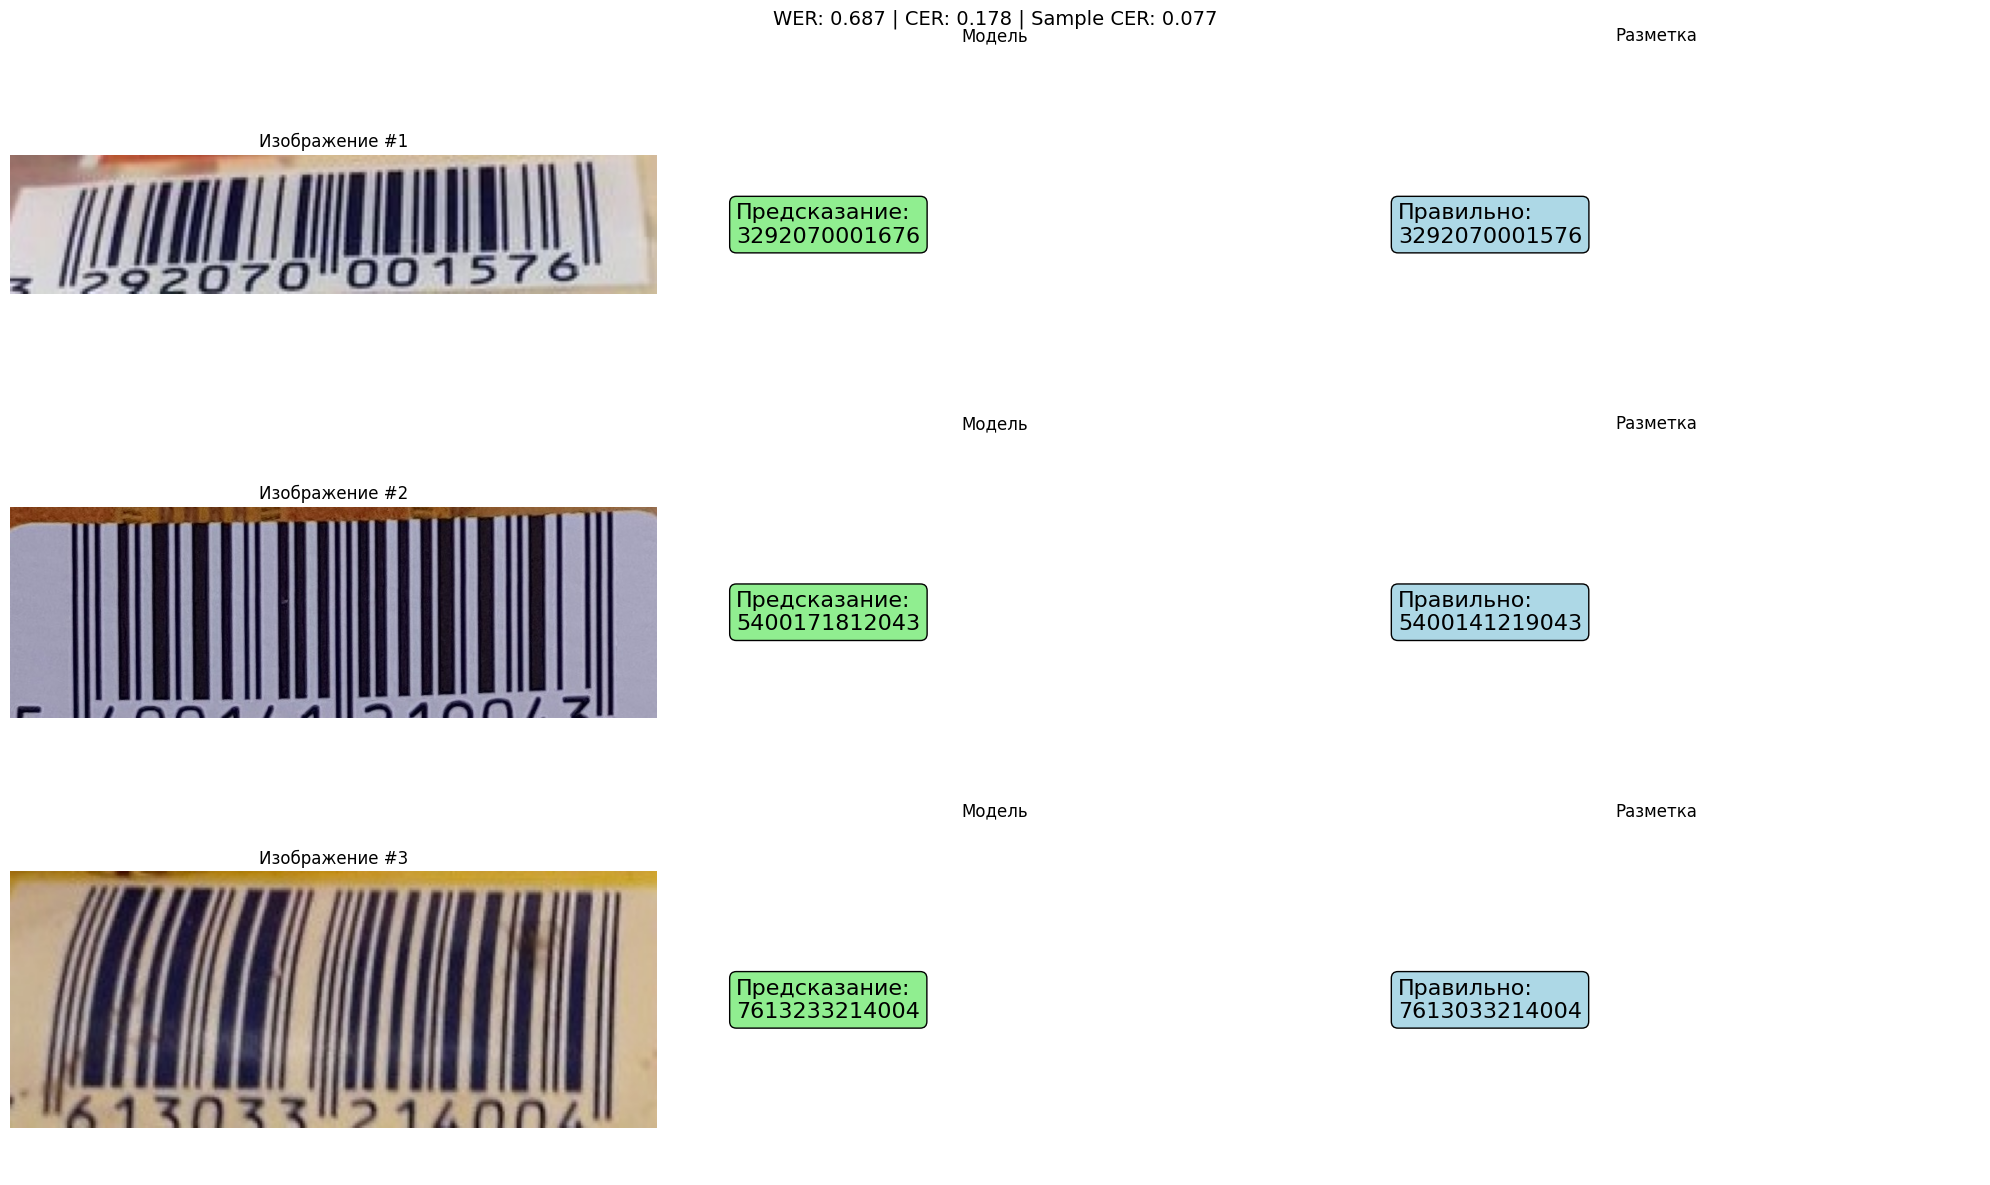

In [ ]:
def visualize_predictions(classification_crnn, test_dataloader, num_samples=4):
    classification_crnn.eval()
    plt.figure(figsize=(20, 4*num_samples))

    with torch.no_grad():
        for i, batch in enumerate(test_dataloader):
            if i >= num_samples:
                break

            images = batch['torch_images'][:1].to(device)  # 1 изображение
            pred = classification_crnn(images).cpu()
            pred_text = decode_classification(pred)[0]
            true_text = batch['text'][0]

            # Визуализация
            img = batch['pil_images'][0]
            plt.subplot(num_samples, 3, i*3+1)
            plt.imshow(img, cmap='gray')
            plt.title(f'Изображение #{i+1}', fontsize=12)
            plt.axis('off')

            plt.subplot(num_samples, 3, i*3+2)
            plt.text(0.1, 0.5, f'Предсказание:\n{pred_text}', fontsize=16,
                    ha='left', va='center', transform=plt.gca().transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
            plt.title('Модель', fontsize=12)
            plt.axis('off')

            plt.subplot(num_samples, 3, i*3+3)
            plt.text(0.1, 0.5, f'Правильно:\n{true_text}', fontsize=16,
                    ha='left', va='center', transform=plt.gca().transAxes,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
            plt.title('Разметка', fontsize=12)
            plt.axis('off')

            # CER для этой пары
            cer = Levenshtein.distance(pred_text, true_text) / len(true_text)
            plt.suptitle(f'WER: 0.687 | CER: 0.178 | Sample CER: {cer:.3f}',
                        fontsize=14, y=0.98)

    plt.tight_layout()
    plt.show()

# Запуск визуализации
visualize_predictions(classification_crnn, test_dataloader, num_samples=4)

In [ ]:
def error_heatmap(predictions, ground_truth):
    pos_errors = np.zeros(13)  # 13 цифр в штрихкоде

    for pred, gt in zip(predictions, ground_truth):
        for i in range(min(13, len(pred), len(gt))):
            if pred[i] != gt[i]:
                pos_errors[i] += 1

    plt.figure(figsize=(12, 4))
    plt.imshow(pos_errors.reshape(1, -1), cmap='Reds', aspect='auto')
    plt.colorbar(label='Количество ошибок')
    plt.xticks(range(13), [f'Позиция {i+1}' for i in range(13)], rotation=45)
    plt.title('Ошибки по позициям штрихкодов')
    plt.ylabel('Батч')
    plt.tight_layout()
    plt.show()


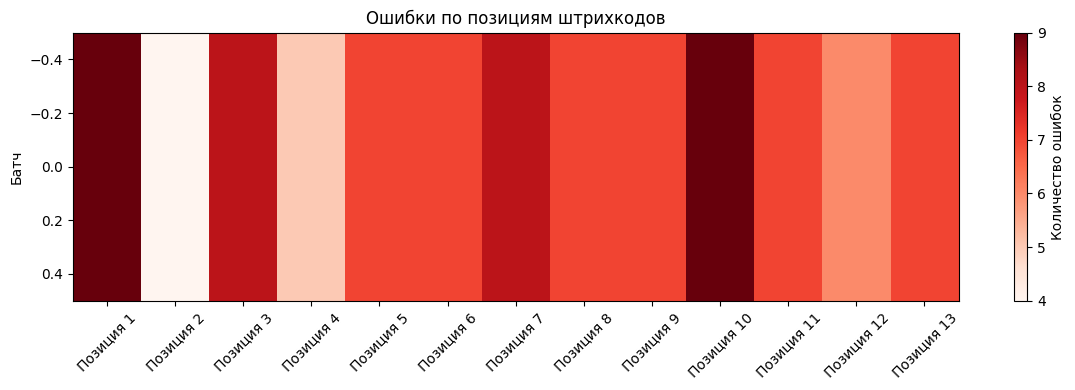

In [ ]:
classification_crnn.eval()
predictions, ground_truth = [], []

with torch.no_grad():
    for batch in test_dataloader:
        preds = classification_crnn(batch['torch_images'][:16].to(device)).cpu()  # 16 примеров
        batch_preds = decode_classification(preds)
        predictions.extend(batch_preds)
        ground_truth.extend(batch['text'][:16])
        break  # Только 1 батч

error_heatmap(predictions, ground_truth)